In [1]:
## This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session


/kaggle/input/breast-cancer-wisconsin-data/data.csv


In [2]:
import h2o

In [3]:
h2o.init()

Checking whether there is an H2O instance running at http://localhost:54321 ..... not found.
Attempting to start a local H2O server...
  Java Version: openjdk version "11.0.15" 2022-04-19; OpenJDK Runtime Environment (build 11.0.15+10-Ubuntu-0ubuntu0.20.04.1); OpenJDK 64-Bit Server VM (build 11.0.15+10-Ubuntu-0ubuntu0.20.04.1, mixed mode, sharing)
  Starting server from /opt/conda/lib/python3.7/site-packages/h2o/backend/bin/h2o.jar
  Ice root: /tmp/tmpixxuywa8
  JVM stdout: /tmp/tmpixxuywa8/h2o_unknownUser_started_from_python.out
  JVM stderr: /tmp/tmpixxuywa8/h2o_unknownUser_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,02 secs
H2O_cluster_timezone:,Etc/UTC
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.36.1.3
H2O_cluster_version_age:,1 month and 1 day
H2O_cluster_name:,H2O_from_python_unknownUser_ohlbl9
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,4.396 Gb
H2O_cluster_total_cores:,4
H2O_cluster_allowed_cores:,4
H2O_cluster_status:,"locked, healthy"


In [4]:
from h2o.estimators.xgboost import H2OXGBoostEstimator

In [5]:
data = h2o.import_file("/kaggle/input/breast-cancer-wisconsin-data/data.csv")

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%


# Define Response Variable and Split Data into Training, Validation and Testing frames

In [6]:
data["diagnosis"] = data["diagnosis"].asfactor()

In [7]:
train, valid, test = data.split_frame(ratios = [0.7, 0.1], seed = 23)
# training = 70%, validation = 10%, testing = 20%

In [8]:
y = "diagnosis" # response variable
preds = list(data.columns) # store ALL columns to predictors
preds.remove(y) # remove response variable from predictors

# XGBoost

In [9]:
params = {
    "ntrees": 200,
    "max_depth": 10,
    "learn_rate": 0.01
}

In [10]:
model_xgb = H2OXGBoostEstimator(**params)

# Training the model

In [11]:
model_xgb.train(x = preds, y = y, training_frame = train, validation_frame = valid)

xgboost Model Build progress: |

/opt/conda/lib/python3.7/site-packages/h2o/estimators/estimator_base.py:208: RuntimeWarning: Dropping bad and constant columns: [C33]
  warnings.warn(mesg["message"], RuntimeWarning)


██████████████████████████████████████████████████| (done) 100%
Model Details
H2OXGBoostEstimator :  XGBoost
Model Key:  XGBoost_model_python_1660148712935_1


Model Summary: 


,,number_of_trees
0,,200.0




ModelMetricsBinomial: xgboost
** Reported on train data. **

MSE: 0.014950253798852571
RMSE: 0.1222712304626586
LogLoss: 0.1105587037727789
Mean Per-Class Error: 0.003424657534246575
AUC: 0.9994200176756517
AUCPR: 0.9991361198269558
Gini: 0.9988400353513034

Confusion Matrix (Act/Pred) for max f1 @ threshold = 0.4214164912700653: 


...



Scoring History: 


,,timestamp,duration,number_of_trees,training_rmse,training_logloss,training_auc,training_pr_auc,training_lift,training_classification_error,validation_rmse,validation_logloss,validation_auc,validation_pr_auc,validation_lift,validation_classification_error
0,,2022-08-10 16:25:19,0.101 sec,0.0,0.500000,0.693147,0.500000,0.370558,1.00000,0.629442,0.500000,0.693147,0.500000,0.358491,1.000000,0.641509
1,,2022-08-10 16:25:20,0.321 sec,1.0,0.495484,0.684156,0.988801,0.990531,2.69863,0.015228,0.495725,0.684633,0.967492,0.895282,2.495845,0.037736
2,,2022-08-10 16:25:20,0.382 sec,2.0,0.491042,0.675389,0.988801,0.990534,2.69863,0.015228,0.491654,0.676593,0.967492,0.895282,2.495845,0.037736
3,,2022-08-10 16:25:20,0.428 sec,3.0,0.486645,0.666787,0.988469,0.990033,2.69863,0.015228,0.487634,0.668715,0.965944,0.893073,2.495845,0.056604
4,,2022-08-10 16:25:20,0.476 sec,4.0,0.482294,0.658346,0.988469,0.990033,2.69863,0.015228,0.483599,0.660867,0.965944,0.893073,2.495845,0.056604
5,,2022-08-10 16:25:20,0.509 sec,5.0,0.477988,0.650061,0.988469,0.990033,2.69863,0.015228,0.479678,0.653300,0.965944,0.893073,2.495845,0.056604
6,,2022-08-10 16:25:20,0.543 sec,6.0,0.473726,0.641929,0.988469,0.990033,2.69863,0.015228,0.475741,0.645757,0.965944,0.893073,2.495845,0.056604
7,,2022-08-10 16:25:20,0.581 sec,7.0,0.469509,0.633945,0.988469,0.990033,2.69863,0.015228,0.471852,0.638362,0.965944,0.893073,2.495845,0.056604
8,,2022-08-10 16:25:20,0.622 sec,8.0,0.465335,0.626105,0.988469,0.990033,2.69863,0.015228,0.468077,0.631229,0.965944,0.893073,2.495845,0.056604
9,,2022-08-10 16:25:20,0.655 sec,9.0,0.461205,0.618405,0.991438,0.992161,2.69863,0.015228,0.464177,0.623915,0.965944,0.893073,2.495845,0.056604



See the whole table with table.as_data_frame()

Variable Importances: 


,variable,relative_importance,scaled_importance,percentage
0,concave points_worst,12910.951172,1.000000,0.601898
1,radius_worst,3922.129150,0.303783,0.182846
2,concave points_mean,1164.842529,0.090221,0.054304
3,area_worst,1068.283081,0.082742,0.049802
4,texture_mean,790.381897,0.061218,0.036847
5,perimeter_worst,532.524536,0.041246,0.024826
6,concavity_worst,233.798859,0.018109,0.010900
7,texture_worst,160.439285,0.012427,0.007480
8,id,132.705948,0.010279,0.006187
9,compactness_mean,112.583183,0.008720,0.005249



See the whole table with table.as_data_frame()


Model Performance

In [12]:
model_xgb.model_performance(valid = True).auc() # training AUC

0.9938080495356038

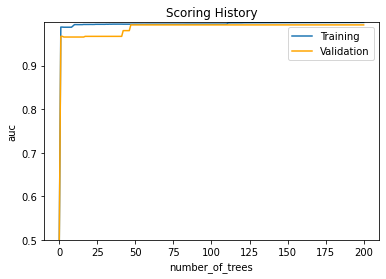

In [13]:
model_xgb.plot(metric = 'auc') # training AUC

In [14]:
model_xgb.model_performance(test_data = test).auc() # testing AUC

0.9843971631205674

## Variable Importance

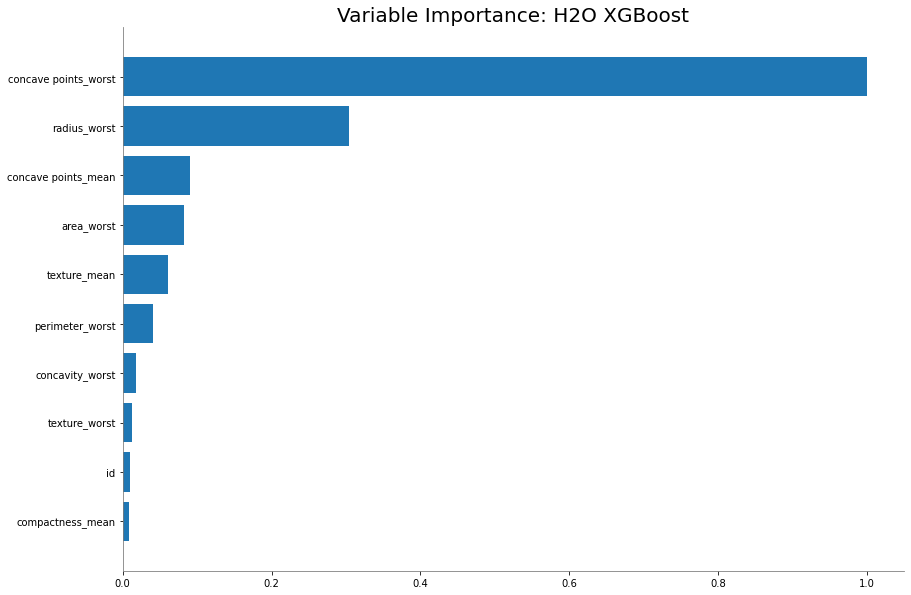

<Figure size 432x288 with 0 Axes>

In [15]:
model_xgb.varimp_plot()